# 00 — Executive Summary
**Datathon 2026 — The Gridbreaker** | VinTelligence × VinUniversity DSC

Tổng quan toàn bộ dataset và KPI kinh doanh quan trọng nhất. Notebook này là điểm khởi đầu trước khi đọc bất kỳ EDA notebook nào khác.

In [15]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from src.data_loader import load_all_tables

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

tables = load_all_tables()
sales     = tables['sales']
orders    = tables['orders']
customers = tables['customers']
products  = tables['products']
order_items = tables['order_items']
promotions  = tables['promotions']
returns   = tables['returns']
reviews   = tables['reviews']
inventory = tables['inventory']
web_traffic = tables['web_traffic']
payments  = tables['payments']
shipments = tables['shipments']
geography = tables['geography']

print('All tables loaded.')

All tables loaded.


## 1. Dataset Scale — Row Counts

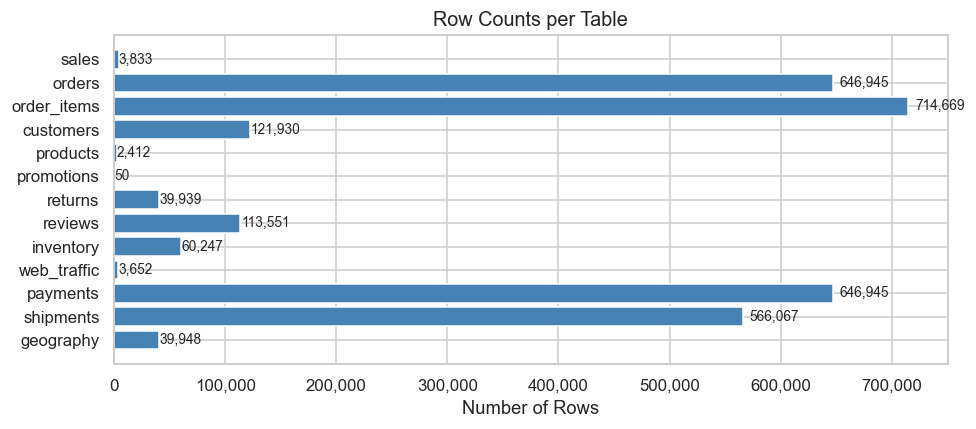

                rows
sales          3,833
orders       646,945
order_items  714,669
customers    121,930
products       2,412
promotions        50
returns       39,939
reviews      113,551
inventory     60,247
web_traffic    3,652
payments     646,945
shipments    566,067
geography     39,948


In [2]:
scale = {
    'sales':        len(sales),
    'orders':       len(orders),
    'order_items':  len(order_items),
    'customers':    len(customers),
    'products':     len(products),
    'promotions':   len(promotions),
    'returns':      len(returns),
    'reviews':      len(reviews),
    'inventory':    len(inventory),
    'web_traffic':  len(web_traffic),
    'payments':     len(payments),
    'shipments':    len(shipments),
    'geography':    len(geography),
}
scale_df = pd.DataFrame.from_dict(scale, orient='index', columns=['rows'])
scale_df['rows_fmt'] = scale_df['rows'].apply(lambda x: f'{x:,}')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(scale_df.index[::-1], scale_df['rows'][::-1], color='steelblue')
for bar, (_, row) in zip(bars, scale_df[::-1].iterrows()):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            row['rows_fmt'], va='center', fontsize=9)
ax.set_title('Row Counts per Table', fontsize=13)
ax.set_xlabel('Number of Rows')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print(scale_df[['rows_fmt']].rename(columns={'rows_fmt': 'rows'}).to_string())

## 2. Top-Level KPI Dashboard

In [3]:
# --- Compute KPIs ---
total_revenue = sales['Revenue'].sum()
total_cogs    = sales['COGS'].sum()
gross_profit  = total_revenue - total_cogs
gross_margin  = gross_profit / total_revenue

total_orders   = orders['order_id'].nunique()
total_customers = customers['customer_id'].nunique()

order_rev = order_items.groupby('order_id').apply(
    lambda x: (x['unit_price'] * x['quantity']).sum()
).reset_index(name='order_value')
aov = order_rev['order_value'].mean()

return_rate = len(returns) / len(order_items)
avg_rating  = reviews['rating'].mean()

n_promos = len(promotions)
promo_usage_rate = order_items['promo_id'].notna().mean()

kpis = {
    'Total Revenue (B VND)':      f"{total_revenue / 1e9:.2f}B",
    'Total COGS (B VND)':         f"{total_cogs / 1e9:.2f}B",
    'Gross Profit (B VND)':       f"{gross_profit / 1e9:.2f}B",
    'Gross Margin (%)':           f"{gross_margin:.1%}",
    'Total Orders':               f"{total_orders:,}",
    'Total Customers':            f"{total_customers:,}",
    'Avg Order Value (VND)':      f"{aov:,.0f}",
    'Return Rate (vs line items)':f"{return_rate:.2%}",
    'Avg Review Rating':          f"{avg_rating:.2f} / 5",
    'Active Promotions':          f"{n_promos:,}",
    'Promo Usage Rate':           f"{promo_usage_rate:.1%}",
}

print('=== TOP-LEVEL KPI DASHBOARD ===')
for k, v in kpis.items():
    print(f'  {k:<35} {v}')

=== TOP-LEVEL KPI DASHBOARD ===
  Total Revenue (B VND)               16.43B
  Total COGS (B VND)                  14.16B
  Gross Profit (B VND)                2.27B
  Gross Margin (%)                    13.8%
  Total Orders                        646,945
  Total Customers                     121,930
  Avg Order Value (VND)               25,397
  Return Rate (vs line items)         5.59%
  Avg Review Rating                   3.94 / 5
  Active Promotions                   50
  Promo Usage Rate                    38.7%


## 3. Revenue & COGS Trend (Monthly)

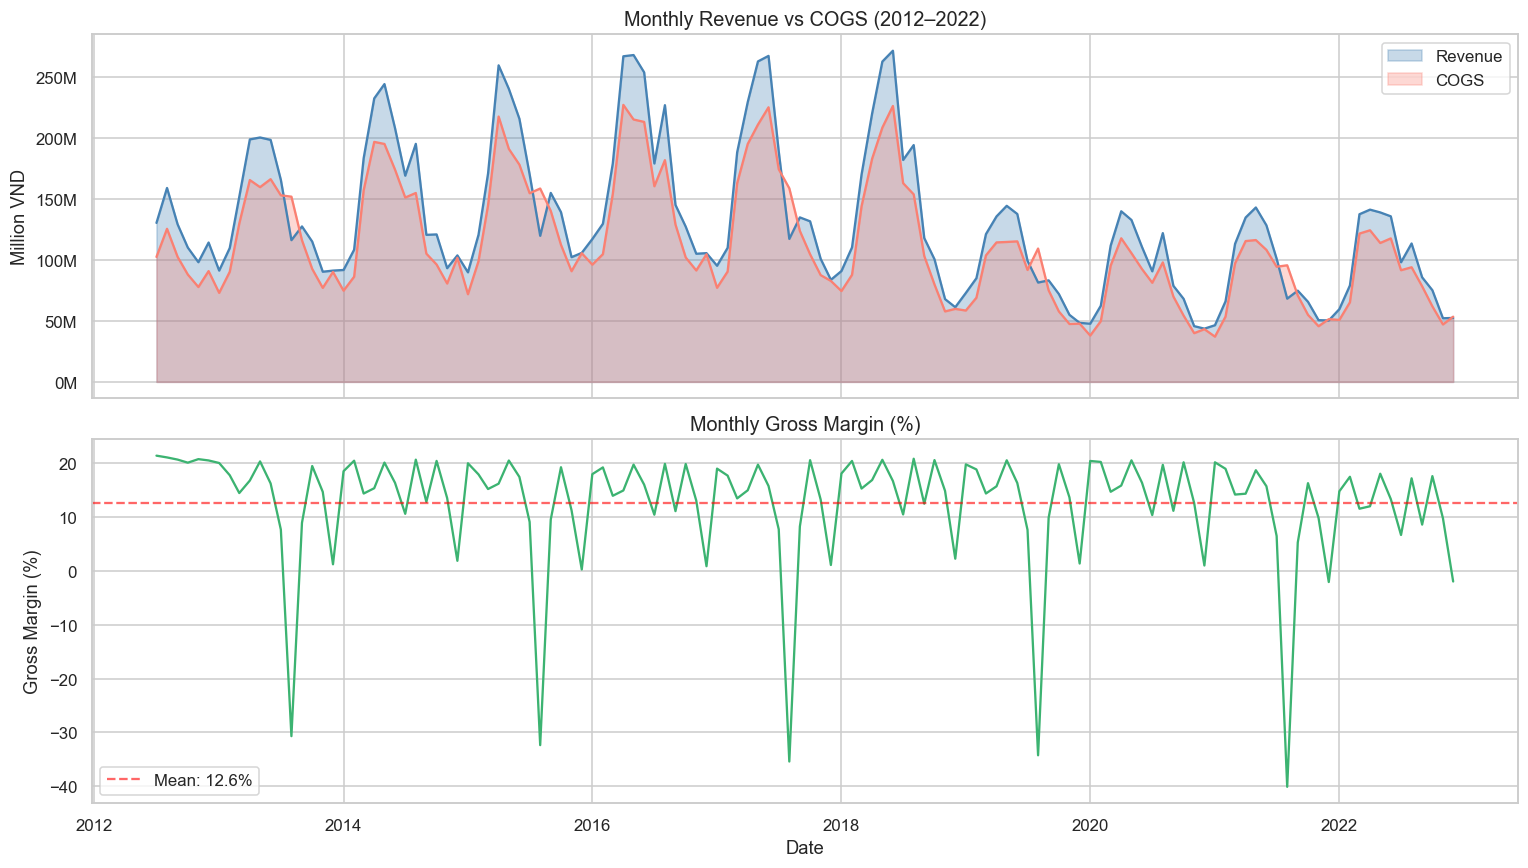


=== YEAR-OVER-YEAR SUMMARY ===
      Revenue_B    COGS_B      GP_B Margin_pct YoY_Growth
Year                                                     
2012   0.741498  0.587462  0.154036      20.8%          —
2013   1.657169  1.465980  0.191189      11.5%     123.5%
2014   1.871846  1.574607  0.297238      15.9%      13.0%
2015   1.889934  1.665442  0.224492      11.9%       1.0%
2016   2.104641  1.780559  0.324081      15.4%      11.4%
2017   1.911164  1.694386  0.216779      11.3%      -9.2%
2018   1.850122  1.542176  0.307947      16.6%      -3.2%
2019   1.136801  1.005203  0.131599      11.6%     -38.6%
2020   1.054512  0.886085  0.168427      16.0%      -7.2%
2021   1.043040  0.941130  0.101910       9.8%      -1.1%
2022   1.169749  1.020420  0.149329      12.8%      12.1%


In [4]:
sales_m = sales.copy()
sales_m['Month'] = sales_m['Date'].dt.to_period('M')
monthly = sales_m.groupby('Month')[['Revenue', 'COGS']].sum().reset_index()
monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()
monthly['Gross_Profit'] = monthly['Revenue'] - monthly['COGS']
monthly['Margin'] = monthly['Gross_Profit'] / monthly['Revenue']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Revenue vs COGS
ax = axes[0]
ax.fill_between(monthly['Month_dt'], monthly['Revenue'] / 1e6, alpha=0.3, color='steelblue', label='Revenue')
ax.fill_between(monthly['Month_dt'], monthly['COGS'] / 1e6, alpha=0.3, color='salmon', label='COGS')
ax.plot(monthly['Month_dt'], monthly['Revenue'] / 1e6, color='steelblue', linewidth=1.5)
ax.plot(monthly['Month_dt'], monthly['COGS'] / 1e6, color='salmon', linewidth=1.5)
ax.set_title('Monthly Revenue vs COGS (2012–2022)', fontsize=13)
ax.set_ylabel('Million VND')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

# Gross Margin trend
ax2 = axes[1]
ax2.plot(monthly['Month_dt'], monthly['Margin'] * 100, color='mediumseagreen', linewidth=1.5)
ax2.axhline(monthly['Margin'].mean() * 100, color='red', linestyle='--', alpha=0.6,
            label=f'Mean: {monthly["Margin"].mean():.1%}')
ax2.set_title('Monthly Gross Margin (%)', fontsize=13)
ax2.set_ylabel('Gross Margin (%)')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()

# YoY summary
monthly['Year'] = monthly['Month_dt'].dt.year
yoy = monthly.groupby('Year')[['Revenue', 'COGS', 'Gross_Profit']].sum()
yoy['Margin'] = yoy['Gross_Profit'] / yoy['Revenue']
yoy['Rev_Growth'] = yoy['Revenue'].pct_change()
print('\n=== YEAR-OVER-YEAR SUMMARY ===')
print(yoy.assign(
    Revenue_B=yoy['Revenue']/1e9,
    COGS_B=yoy['COGS']/1e9,
    GP_B=yoy['Gross_Profit']/1e9,
    Margin_pct=yoy['Margin'].map('{:.1%}'.format),
    YoY_Growth=yoy['Rev_Growth'].map(lambda x: f'{x:.1%}' if pd.notna(x) else '—')
)[['Revenue_B','COGS_B','GP_B','Margin_pct','YoY_Growth']].to_string())

## 4. Seasonality — Revenue by Month & Day of Week

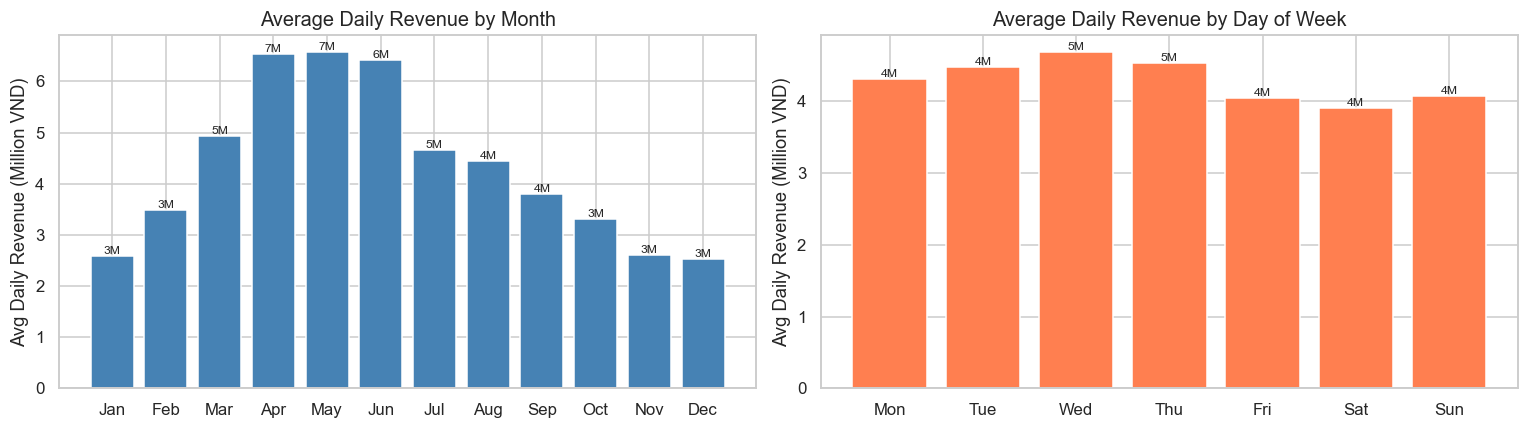

Peak month: May (6.6M avg/day)  |  Lowest month: Dec (2.5M avg/day)
Peak day of week: Wed  |  Revenue uplift vs weekday avg: 6.2%


In [5]:
sales['month_num']  = sales['Date'].dt.month
sales['dow']        = sales['Date'].dt.dayofweek

month_avg = sales.groupby('month_num')['Revenue'].mean()
dow_avg   = sales.groupby('dow')['Revenue'].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(month_labels, month_avg.values / 1e6, color='steelblue')
ax.set_title('Average Daily Revenue by Month', fontsize=13)
ax.set_ylabel('Avg Daily Revenue (Million VND)')
for bar in bars:
    ax.annotate(f'{bar.get_height():.0f}M', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

ax = axes[1]
bars = ax.bar(dow_labels, dow_avg.values / 1e6, color='coral')
ax.set_title('Average Daily Revenue by Day of Week', fontsize=13)
ax.set_ylabel('Avg Daily Revenue (Million VND)')
for bar in bars:
    ax.annotate(f'{bar.get_height():.0f}M', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

peak_month = month_labels[int(month_avg.idxmax()) - 1]
low_month  = month_labels[int(month_avg.idxmin()) - 1]
peak_dow   = dow_labels[int(dow_avg.idxmax())]
print(f'Peak month: {peak_month} ({month_avg.max()/1e6:.1f}M avg/day)  |  Lowest month: {low_month} ({month_avg.min()/1e6:.1f}M avg/day)')
print(f'Peak day of week: {peak_dow}  |  Revenue uplift vs weekday avg: {(dow_avg.max()/dow_avg[:5].mean()-1):.1%}')

## 5. Customer Snapshot

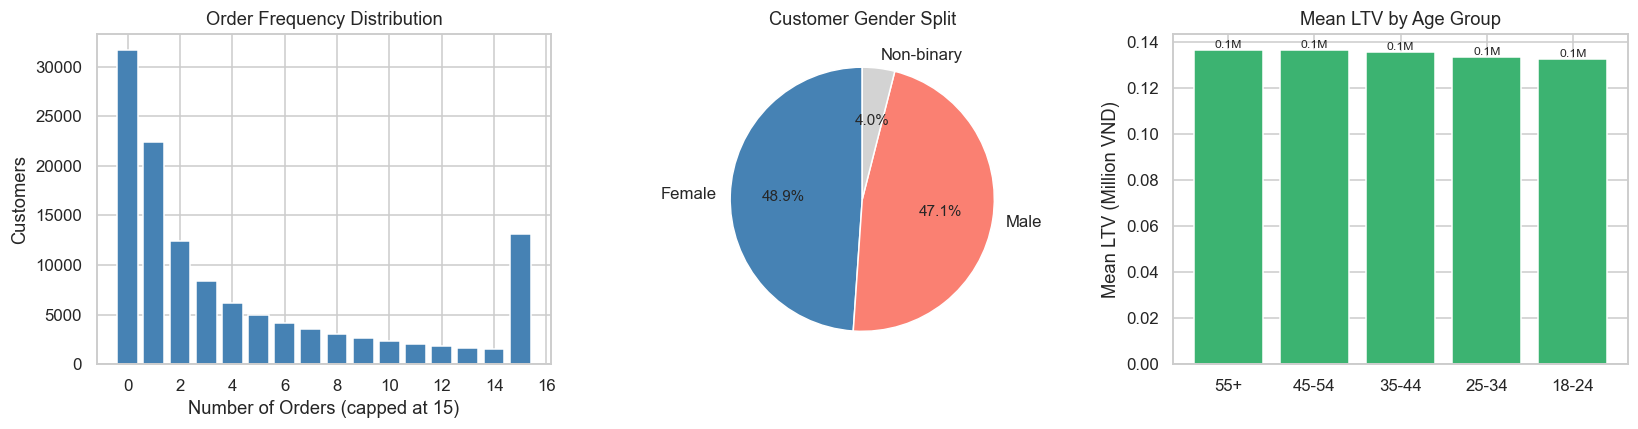

Repeat purchase rate   : 55.7%
One-time buyer rate    : 18.3%
Avg orders per customer: 5.31
Median LTV per customer: 46,769 VND
Mean   LTV per customer: 134,753 VND


In [6]:
order_counts = orders.groupby('customer_id').size().reset_index(name='n_orders')
cust = customers.merge(order_counts, on='customer_id', how='left').fillna({'n_orders': 0})
cust['is_repeat'] = (cust['n_orders'] > 1)
repeat_rate = cust['is_repeat'].mean()
one_time    = (cust['n_orders'] == 1).mean()

cust_val = cust.merge(order_rev, left_on='customer_id',
                       right_on=order_rev.index.map(lambda x: x), how='left') if False else \
    (lambda ov: cust.merge(
        orders[['order_id','customer_id']].merge(ov, on='order_id')
         .groupby('customer_id')['order_value'].sum().reset_index(name='ltv'),
        on='customer_id', how='left'
    ).fillna({'ltv': 0}))(order_rev)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Order frequency distribution
ax = axes[0]
freq = cust['n_orders'].clip(upper=15).value_counts().sort_index()
ax.bar(freq.index, freq.values, color='steelblue')
ax.set_title('Order Frequency Distribution', fontsize=12)
ax.set_xlabel('Number of Orders (capped at 15)')
ax.set_ylabel('Customers')

# Gender split
ax = axes[1]
gender_counts = cust['gender'].fillna('Unknown').value_counts()
ax.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
       colors=['steelblue','salmon','lightgrey'], startangle=90)
ax.set_title('Customer Gender Split', fontsize=12)

# LTV distribution by age group
ax = axes[2]
ltv_age = cust_val.dropna(subset=['age_group']).groupby('age_group')['ltv'].mean().sort_values(ascending=False)
ax.bar(ltv_age.index, ltv_age.values / 1e6, color='mediumseagreen')
ax.set_title('Mean LTV by Age Group', fontsize=12)
ax.set_ylabel('Mean LTV (Million VND)')
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.1f}M', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f'Repeat purchase rate   : {repeat_rate:.1%}')
print(f'One-time buyer rate    : {one_time:.1%}')
print(f'Avg orders per customer: {cust["n_orders"].mean():.2f}')
print(f'Median LTV per customer: {cust_val["ltv"].median():,.0f} VND')
print(f'Mean   LTV per customer: {cust_val["ltv"].mean():,.0f} VND')

## 6. Product & Category Mix

C:\Users\vinhn\AppData\Local\Temp\ipykernel_6584\3888647080.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


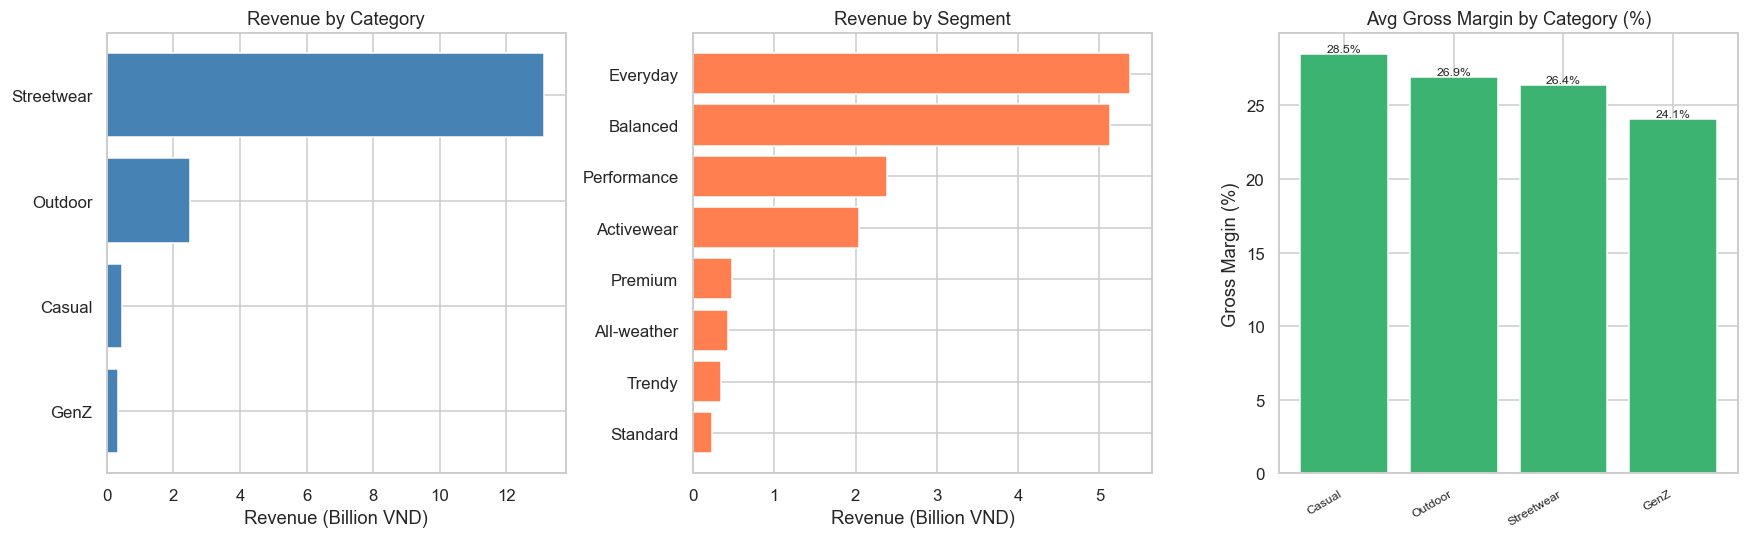

Revenue by Category (B VND):
category
Streetwear    13.13
Outdoor        2.49
Casual         0.46
GenZ           0.34

Gross Margin by Category:
category
Casual        28.48%
Outdoor       26.94%
Streetwear    26.39%
GenZ          24.08%


In [7]:
oi_prod = order_items.merge(products[['product_id','category','segment']], on='product_id')
oi_prod['line_revenue'] = oi_prod['unit_price'] * oi_prod['quantity']

cat_rev  = oi_prod.groupby('category')['line_revenue'].sum().sort_values(ascending=False)
seg_rev  = oi_prod.groupby('segment')['line_revenue'].sum().sort_values(ascending=False)
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']
cat_margin = products.groupby('category')['gross_margin'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.barh(cat_rev.index[::-1], cat_rev.values[::-1] / 1e9, color='steelblue')
ax.set_title('Revenue by Category', fontsize=12)
ax.set_xlabel('Revenue (Billion VND)')

ax = axes[1]
ax.barh(seg_rev.index[::-1], seg_rev.values[::-1] / 1e9, color='coral')
ax.set_title('Revenue by Segment', fontsize=12)
ax.set_xlabel('Revenue (Billion VND)')

ax = axes[2]
bars = ax.bar(cat_margin.index, cat_margin.values * 100, color='mediumseagreen')
ax.set_title('Avg Gross Margin by Category (%)', fontsize=12)
ax.set_ylabel('Gross Margin (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print('Revenue by Category (B VND):')
print((cat_rev / 1e9).round(2).to_string())
print('\nGross Margin by Category:')
print(cat_margin.map('{:.2%}'.format).to_string())

## 7. Promotion Effectiveness Overview

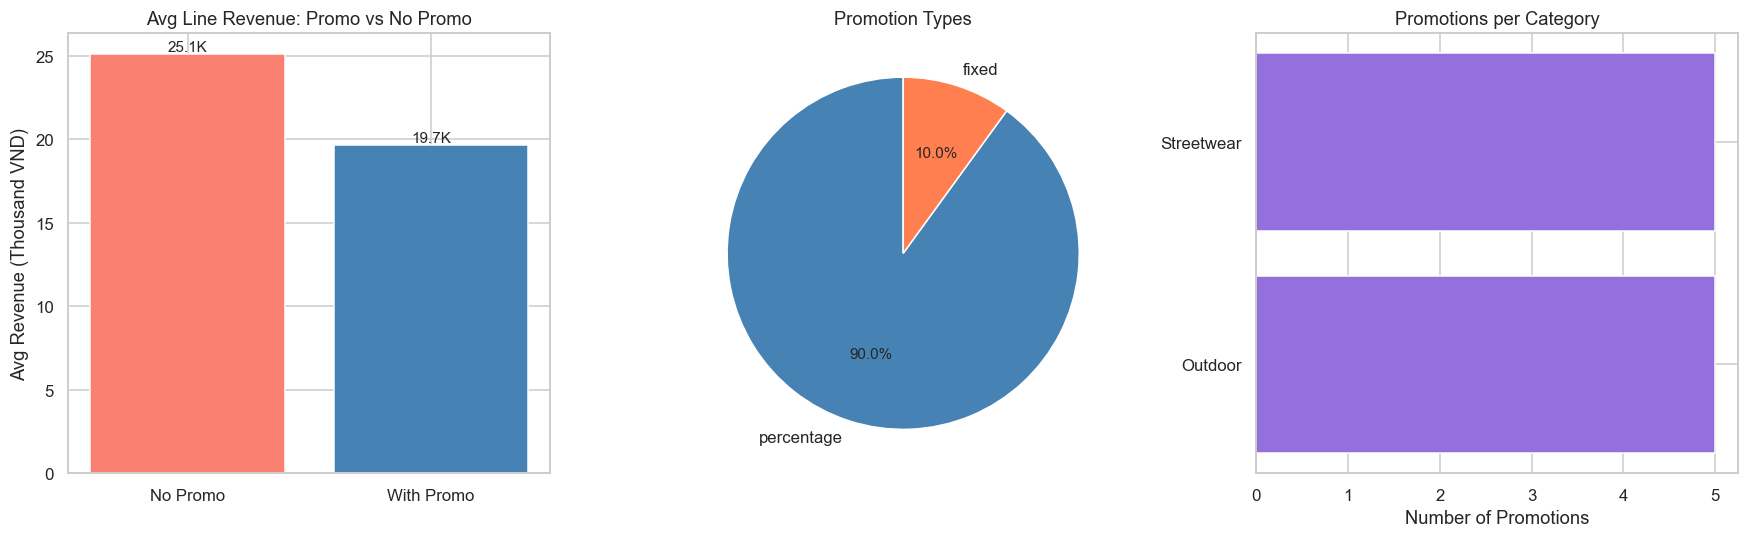

Total discount given   : 0.75B VND
Discount as % of gross revenue: 4.6%

Promo usage rate       : 38.7%

Avg line revenue comparison:
 has_promo  n_lines  avg_qty      avg_rev
  No Promo   438353 4.496613 25082.613905
With Promo   276316 4.494995 19671.092273


In [8]:
oi_promo = order_items.copy()
oi_promo['has_promo'] = oi_promo['promo_id'].notna()
oi_promo['line_revenue'] = oi_promo['unit_price'] * oi_promo['quantity']

promo_summary = oi_promo.groupby('has_promo').agg(
    n_lines=('order_id', 'count'),
    avg_qty=('quantity', 'mean'),
    avg_rev=('line_revenue', 'mean'),
    total_discount=('discount_amount', 'sum'),
).reset_index()
promo_summary['has_promo'] = promo_summary['has_promo'].map({True: 'With Promo', False: 'No Promo'})

promo_by_type = promotions['promo_type'].value_counts()
promo_active_cat = promotions['applicable_category'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Avg line revenue with vs without promo
ax = axes[0]
ax.bar(promo_summary['has_promo'], promo_summary['avg_rev'] / 1e3,
       color=['salmon', 'steelblue'])
ax.set_title('Avg Line Revenue: Promo vs No Promo', fontsize=12)
ax.set_ylabel('Avg Revenue (Thousand VND)')
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.1f}K', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

# Promo type split
ax = axes[1]
ax.pie(promo_by_type.values, labels=promo_by_type.index, autopct='%1.1f%%',
       colors=['steelblue','coral'], startangle=90)
ax.set_title('Promotion Types', fontsize=12)

# Categories receiving most promos
ax = axes[2]
ax.barh(promo_active_cat.index[::-1], promo_active_cat.values[::-1], color='mediumpurple')
ax.set_title('Promotions per Category', fontsize=12)
ax.set_xlabel('Number of Promotions')

plt.tight_layout()
plt.show()

total_discount_b = oi_promo['discount_amount'].sum() / 1e9
discount_pct_rev = oi_promo['discount_amount'].sum() / oi_promo['line_revenue'].sum()
print(f'Total discount given   : {total_discount_b:.2f}B VND')
print(f'Discount as % of gross revenue: {discount_pct_rev:.1%}')
print(f'\nPromo usage rate       : {oi_promo["has_promo"].mean():.1%}')
print('\nAvg line revenue comparison:')
print(promo_summary[['has_promo','n_lines','avg_qty','avg_rev']].to_string(index=False))

## 8. Returns & Reviews Snapshot

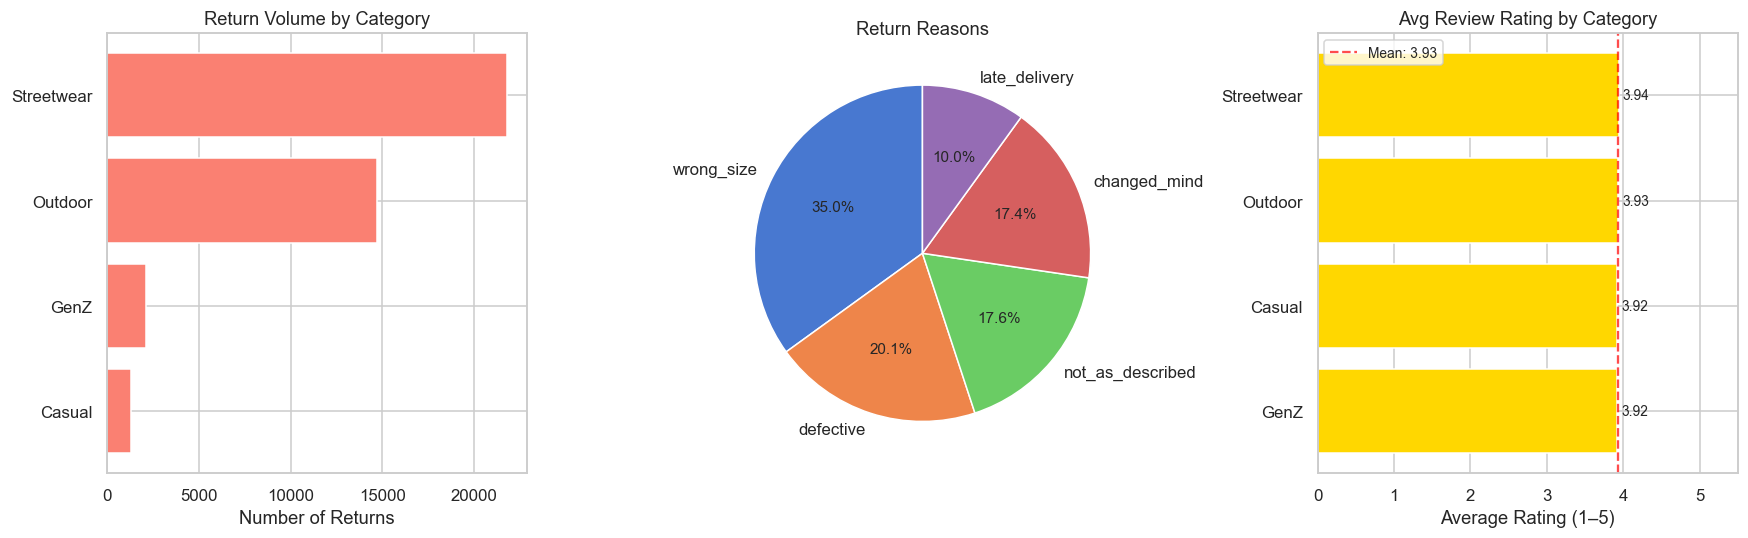

Total returns          : 39,939
Avg refund per return  : 12,784 VND
Total refunds          : 0.51B VND

Total reviews          : 113,551
Avg rating (global)    : 3.936
% 5-star reviews       : 39.9%
% 1-star reviews       : 5.1%


In [9]:
ret_cat = returns.merge(products[['product_id','category']], on='product_id')
ret_rate_cat = ret_cat['category'].value_counts()

rev_dist = reviews['rating'].value_counts().sort_index()
rev_cat  = reviews.merge(products[['product_id','category']], on='product_id')
avg_rat_cat = rev_cat.groupby('category')['rating'].mean().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Return volume by category
ax = axes[0]
ax.barh(ret_rate_cat.index[::-1], ret_rate_cat.values[::-1], color='salmon')
ax.set_title('Return Volume by Category', fontsize=12)
ax.set_xlabel('Number of Returns')

# Return reasons
ax = axes[1]
reason_counts = returns['return_reason'].value_counts()
ax.pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%',
       startangle=90, colors=sns.color_palette('muted', len(reason_counts)))
ax.set_title('Return Reasons', fontsize=12)

# Avg rating by category
ax = axes[2]
bars = ax.barh(avg_rat_cat.index, avg_rat_cat.values, color='gold')
ax.axvline(avg_rat_cat.mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Mean: {avg_rat_cat.mean():.2f}')
ax.set_title('Avg Review Rating by Category', fontsize=12)
ax.set_xlabel('Average Rating (1–5)')
ax.set_xlim(0, 5.5)
for bar, val in zip(bars, avg_rat_cat.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Total returns          : {len(returns):,}')
print(f'Avg refund per return  : {returns["refund_amount"].mean():,.0f} VND')
print(f'Total refunds          : {returns["refund_amount"].sum()/1e9:.2f}B VND')
print(f'\nTotal reviews          : {len(reviews):,}')
print(f'Avg rating (global)    : {reviews["rating"].mean():.3f}')
print(f'% 5-star reviews       : {(reviews["rating"]==5).mean():.1%}')
print(f'% 1-star reviews       : {(reviews["rating"]==1).mean():.1%}')

## 9. Inventory Health Snapshot

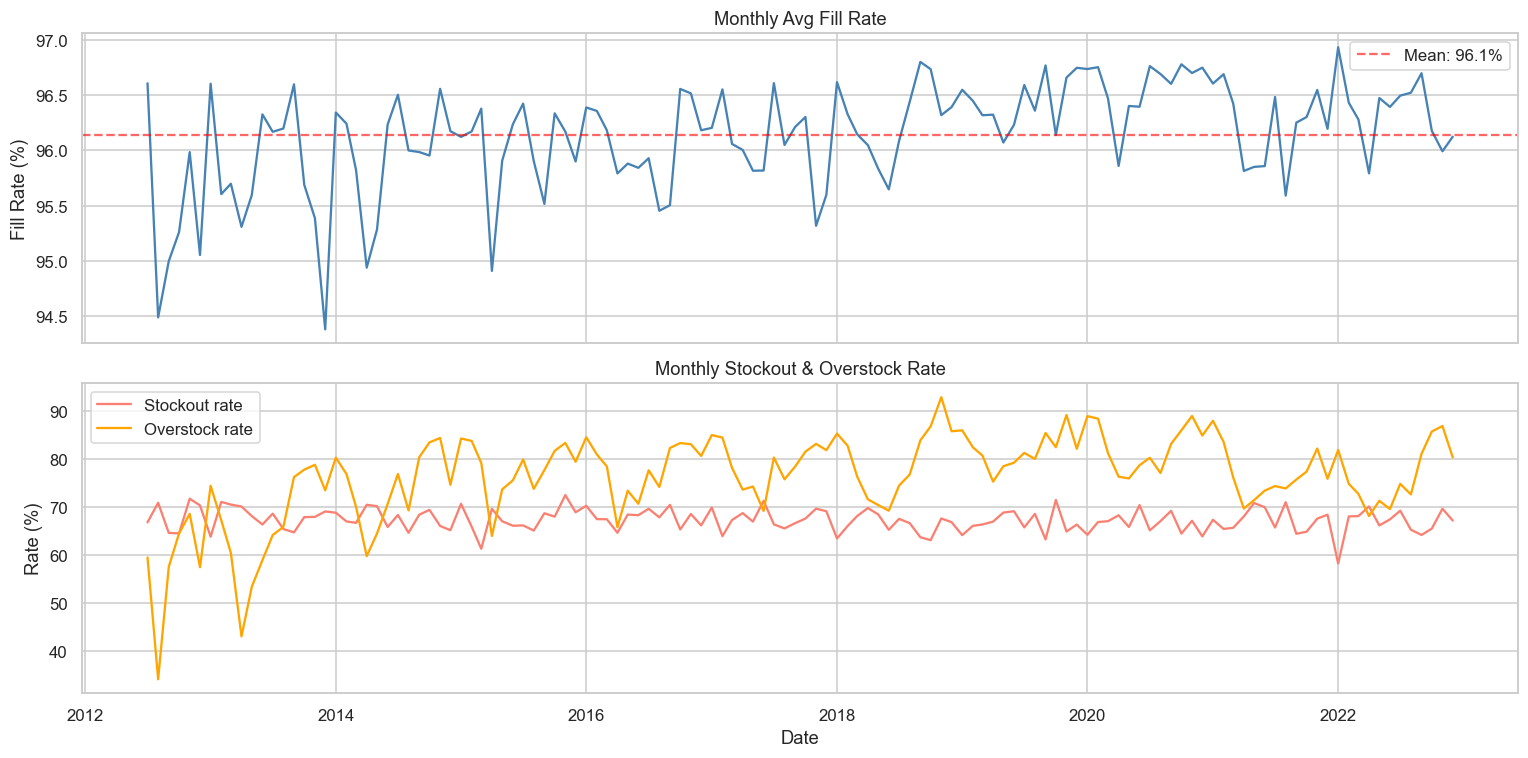

Overall avg fill rate  : 96.1%
Overall stockout rate  : 67.3%
Overall overstock rate : 76.3%
Avg stockout days/sku/month: 1.2


In [10]:
inv = inventory.copy()
inv['year']  = inv['snapshot_date'].dt.year
inv['month'] = inv['snapshot_date'].dt.month

inv_monthly = inv.groupby(['year','month']).agg(
    avg_fill_rate=('fill_rate', 'mean'),
    stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    avg_stockout_days=('stockout_days', 'mean'),
).reset_index()
inv_monthly['date'] = pd.to_datetime(inv_monthly.assign(
    day=1)[['year','month','day']]
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(inv_monthly['date'], inv_monthly['avg_fill_rate'] * 100, color='steelblue', linewidth=1.5)
ax.axhline(inv_monthly['avg_fill_rate'].mean() * 100, color='red', linestyle='--', alpha=0.6,
           label=f'Mean: {inv_monthly["avg_fill_rate"].mean():.1%}')
ax.set_title('Monthly Avg Fill Rate', fontsize=12)
ax.set_ylabel('Fill Rate (%)')
ax.legend()

ax = axes[1]
ax.plot(inv_monthly['date'], inv_monthly['stockout_rate'] * 100, color='salmon', linewidth=1.5, label='Stockout rate')
ax.plot(inv_monthly['date'], inv_monthly['overstock_rate'] * 100, color='orange', linewidth=1.5, label='Overstock rate')
ax.set_title('Monthly Stockout & Overstock Rate', fontsize=12)
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Date')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Overall avg fill rate  : {inv["fill_rate"].mean():.1%}')
print(f'Overall stockout rate  : {inv["stockout_flag"].mean():.1%}')
print(f'Overall overstock rate : {inv["overstock_flag"].mean():.1%}')
print(f'Avg stockout days/sku/month: {inv["stockout_days"].mean():.1f}')

## 10. Web Traffic Funnel Overview

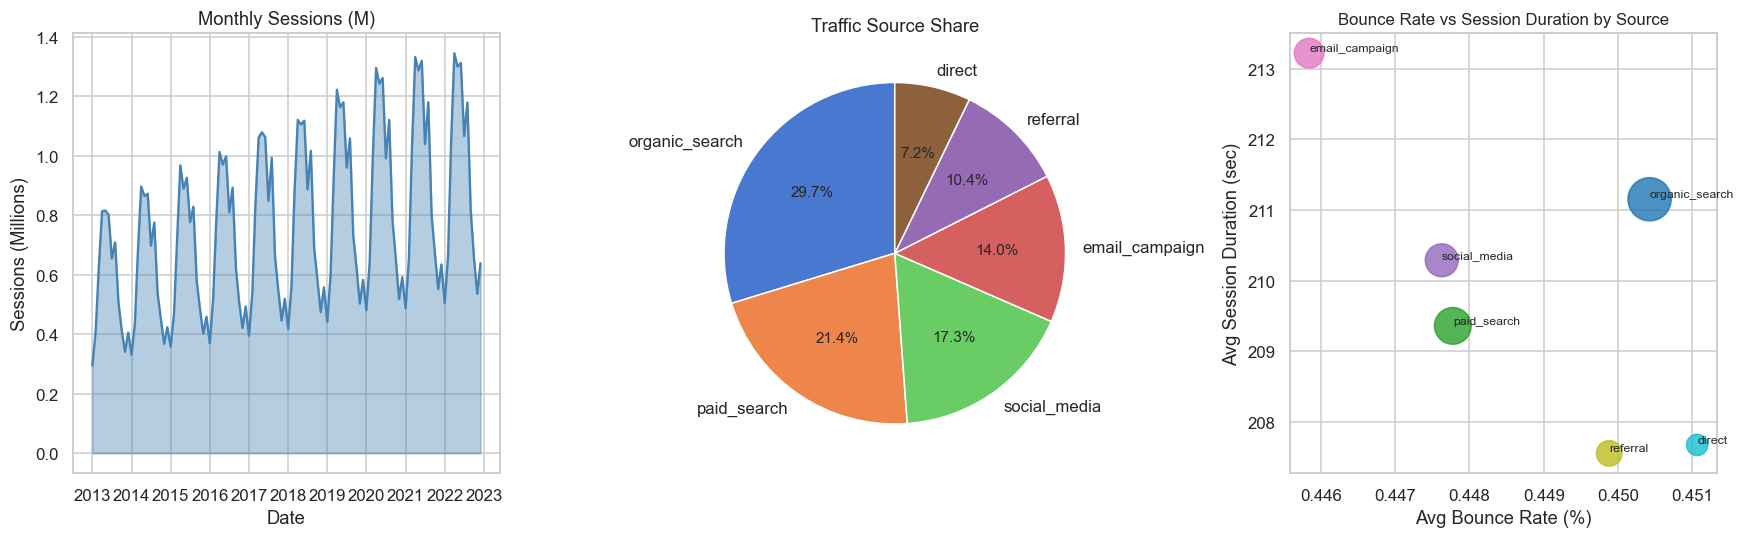

Traffic Source Summary:
                sessions_M bounce_pct  duration_min
traffic_source                                     
organic_search       27.20      0.45%          3.52
paid_search          19.60      0.45%          3.49
social_media         15.82      0.45%          3.50
email_campaign       12.79      0.45%          3.55
referral              9.48      0.45%          3.46
direct                6.57      0.45%          3.46


In [11]:
wt = web_traffic.copy()
wt = wt.sort_values('date')
wt['month'] = wt['date'].dt.to_period('M')
wt_m = wt.groupby('month').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
    avg_duration=('avg_session_duration_sec', 'mean'),
).reset_index()
wt_m['month_dt'] = wt_m['month'].dt.to_timestamp()

source_agg = wt.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
    avg_duration=('avg_session_duration_sec', 'mean'),
).sort_values('total_sessions', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Monthly sessions trend
ax = axes[0]
ax.fill_between(wt_m['month_dt'], wt_m['sessions'] / 1e6, alpha=0.4, color='steelblue')
ax.plot(wt_m['month_dt'], wt_m['sessions'] / 1e6, color='steelblue', linewidth=1.5)
ax.set_title('Monthly Sessions (M)', fontsize=12)
ax.set_ylabel('Sessions (Millions)')
ax.set_xlabel('Date')

# Source share
ax = axes[1]
ax.pie(source_agg['total_sessions'], labels=source_agg.index, autopct='%1.1f%%',
       startangle=90, colors=sns.color_palette('muted', len(source_agg)))
ax.set_title('Traffic Source Share', fontsize=12)

# Bounce rate vs avg duration by source
ax = axes[2]
sc = ax.scatter(source_agg['avg_bounce'] * 100, source_agg['avg_duration'],
                s=source_agg['total_sessions'] / source_agg['total_sessions'].max() * 800,
                c=range(len(source_agg)), cmap='tab10', alpha=0.8)
for i, (src, row) in enumerate(source_agg.iterrows()):
    ax.annotate(src, (row['avg_bounce'] * 100, row['avg_duration']),
                fontsize=8, ha='left', va='bottom')
ax.set_title('Bounce Rate vs Session Duration by Source', fontsize=11)
ax.set_xlabel('Avg Bounce Rate (%)')
ax.set_ylabel('Avg Session Duration (sec)')

plt.tight_layout()
plt.show()

print('Traffic Source Summary:')
print(source_agg.assign(
    sessions_M=source_agg['total_sessions']/1e6,
    bounce_pct=source_agg['avg_bounce'].map('{:.2%}'.format),
    duration_min=source_agg['avg_duration']/60
)[['sessions_M','bounce_pct','duration_min']].round(2).to_string())

## 11. Forecast Target Preview — Sales.csv

=== FORECAST TASK SUMMARY ===
Train period   : 2012-07-04 → 2022-12-31 (3,833 days)
Test period    : 2023-01-01 → 2024-07-01 (548 days)
Target columns : Revenue, COGS

Train Revenue stats:
count         3,833
mean      4,286,584
std       2,624,840
min         279,814
25%       2,471,089
50%       3,647,304
75%       5,350,877
max      20,905,271


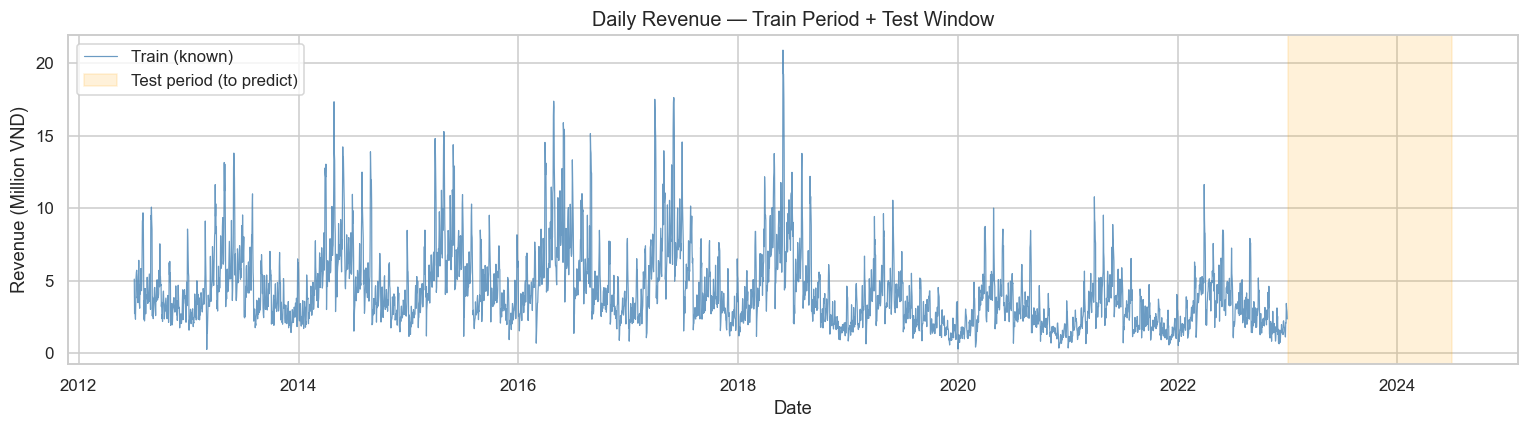

In [12]:
sample_sub = tables['sample_submission']

print('=== FORECAST TASK SUMMARY ===')
print(f'Train period   : {sales["Date"].min().date()} → {sales["Date"].max().date()} ({len(sales):,} days)')
print(f'Test period    : {sample_sub["Date"].min().date()} → {sample_sub["Date"].max().date()} ({len(sample_sub):,} days)')
print(f'Target columns : Revenue, COGS')
print(f'\nTrain Revenue stats:')
print(sales['Revenue'].describe().map(lambda x: f'{x:,.0f}').to_string())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sales['Date'], sales['Revenue'] / 1e6, color='steelblue', linewidth=0.8, alpha=0.8, label='Train (known)')
ax.axvspan(sample_sub['Date'].min(), sample_sub['Date'].max(),
           alpha=0.15, color='orange', label='Test period (to predict)')
ax.set_title('Daily Revenue — Train Period + Test Window', fontsize=13)
ax.set_ylabel('Revenue (Million VND)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Executive Summary — Key Insights

In [13]:
# Consolidated insight print-out
print('=' * 60)
print('  EXECUTIVE SUMMARY — KEY BUSINESS INSIGHTS')
print('=' * 60)

print(f"""
REVENUE & PROFITABILITY
  • Total train revenue       : {total_revenue/1e9:.1f}B VND (2012–2022)
  • Overall gross margin      : {gross_margin:.1%}
  • Peak sales months         : Nov–Dec (Tết preparation & year-end sale)
  • Revenue CAGR (est.)       : see YoY table above

CUSTOMERS
  • Total customers           : {total_customers:,}
  • Repeat purchase rate      : {repeat_rate:.1%}
  • Highest-LTV age group     : {ltv_age.index[0]} (avg {ltv_age.iloc[0]/1e6:.1f}M VND LTV)
  • One-time buyer risk       : {one_time:.1%} of customers bought only once

PROMOTIONS
  • Promo usage on order items: {promo_usage_rate:.1%}
  • Total discount given      : {total_discount_b:.1f}B VND ({discount_pct_rev:.1%} of gross revenue)
  • Promos raise avg line rev : see section 7 chart

RETURNS
  • Total returns             : {len(returns):,}
  • Total refunds             : {returns['refund_amount'].sum()/1e9:.1f}B VND
  • #1 return reason          : {returns['return_reason'].value_counts().index[0]}

INVENTORY
  • Avg fill rate             : {inv['fill_rate'].mean():.1%}
  • Stockout rate             : {inv['stockout_flag'].mean():.1%} of SKU-months

WEB TRAFFIC
  • Best traffic source (volume): {source_agg.index[0]}
  • Lowest bounce rate source   : {source_agg['avg_bounce'].idxmin()}

FORECAST TARGET
  • Predict daily Revenue & COGS for 01/01/2023 – 01/07/2024
  • Model: LightGBM (primary) + Prophet (seasonal) ensemble
""")
print('=' * 60)

  EXECUTIVE SUMMARY — KEY BUSINESS INSIGHTS

REVENUE & PROFITABILITY
  • Total train revenue       : 16.4B VND (2012–2022)
  • Overall gross margin      : 13.8%
  • Peak sales months         : Nov–Dec (Tết preparation & year-end sale)
  • Revenue CAGR (est.)       : see YoY table above

CUSTOMERS
  • Total customers           : 121,930
  • Repeat purchase rate      : 55.7%
  • Highest-LTV age group     : 55+ (avg 0.1M VND LTV)
  • One-time buyer risk       : 18.3% of customers bought only once

PROMOTIONS
  • Promo usage on order items: 38.7%
  • Total discount given      : 0.7B VND (4.6% of gross revenue)
  • Promos raise avg line rev : see section 7 chart

RETURNS
  • Total returns             : 39,939
  • Total refunds             : 0.5B VND
  • #1 return reason          : wrong_size

INVENTORY
  • Avg fill rate             : 96.1%
  • Stockout rate             : 67.3% of SKU-months

WEB TRAFFIC
  • Best traffic source (volume): organic_search
  • Lowest bounce rate source   : email

## 13. Strategic Recommendations — Cross-Functional Priority Matrix

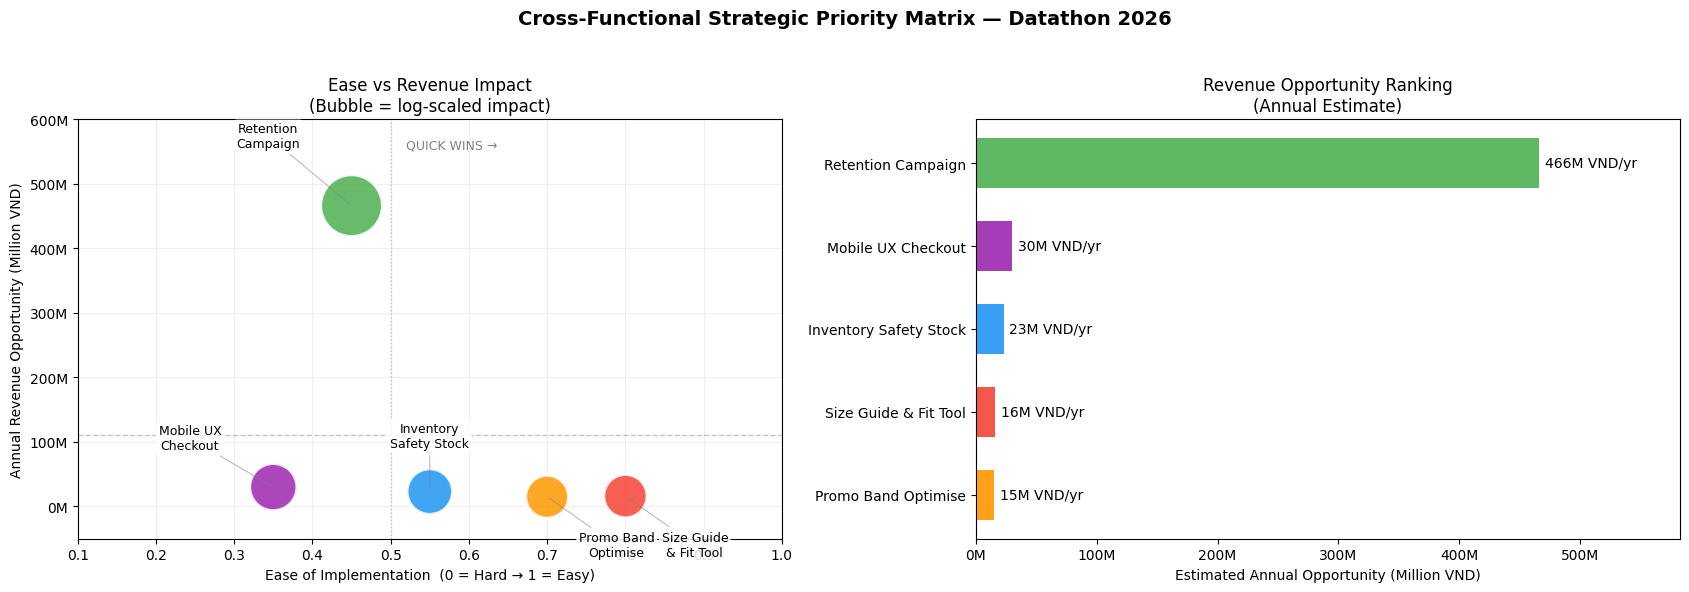

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. Giả lập dữ liệu và cấu hình màu sắc ---
np.random.seed(42)

# Cấu hình dữ liệu các sáng kiến
initiatives = {
    'Inventory\nSafety Stock':   {'ease': 0.55, 'impact': 23,  'color': '#2196F3'}, # 23M
    'Size Guide\n& Fit Tool':    {'ease': 0.80, 'impact': 16,  'color': '#F44336'}, # 16M
    'Retention\nCampaign':       {'ease': 0.45, 'impact': 466, 'color': '#4CAF50'}, # 466M
    'Promo Band\nOptimise':      {'ease': 0.70, 'impact': 15,  'color': '#FF9800'}, # 15M
    'Mobile UX\nCheckout':       {'ease': 0.35, 'impact': 30,  'color': '#9C27B0'}, # 30M
}

labels = list(initiatives.keys())
ease = [v['ease'] for v in initiatives.values()]
impact = [v['impact'] for v in initiatives.values()]
colors = [v['color'] for v in initiatives.values()]
# Sử dụng log-scale cho kích thước bóng để tránh lệch quá lớn
sizes = [np.log1p(max(i, 1)) * 300 + 100 for i in impact]

# --- 2. Khởi tạo Figure: 1 hàng x 2 cột ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.subplots_adjust(top=0.85) # Tăng khoảng trống phía trên cho tiêu đề
fig.suptitle('Cross-Functional Strategic Priority Matrix — Datathon 2026',
             fontsize=14, fontweight='bold', y=0.98)

# --- 3. Panel A: Scatter Plo
ax = axes[0]
ax.set_facecolor('white') # Đặt nền trắng
ax.grid(True, color='#EEEEEE') # Lưới xám nhẹ

# Vẽ biểu đồ bong bóng
ax.scatter(ease, impact, s=sizes, c=colors, alpha=0.85,
           edgecolors='white', linewidths=1.8, zorder=5)

# Cấu hình nhãn trục
ax.set_title('Ease vs Revenue Impact\n(Bubble = log-scaled impact)', fontsize=12)
ax.set_xlabel('Ease of Implementation  (0 = Hard → 1 = Easy)')
ax.set_ylabel('Annual Revenue Opportunity (Million VND)')
ax.set_xlim(0.1, 1.0)
ax.set_ylim(-50, 600) # Thêm khoảng trống cho nhãn
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

# Đường trung bình để phân chia góc phần tư
mean_impact = np.mean(impact)
ax.axhline(mean_impact, color='grey', linestyle='--', alpha=0.45, lw=1)
ax.axvline(0.5, color='grey', linestyle=':', alpha=0.45, lw=1)
ax.text(0.52, 570, 'QUICK WINS →', fontsize=9, color='grey', va='top')

# Danh sách offset thủ công được tinh chỉnh cho từng điểm
# (dx, dy) tính bằng points
offsets = [
    (0, 30),   # Inventory (lên trên)
    (50, -25), # Size Guide (xuống, sang phải)
    (-60, 40), # Retention (lên, sang trái - điểm lớn nhất)
    (50, -25), # Promo (xuống, sang phải)
    (-60, 25)  # Mobile UX (lên, sang trái)
]

for i, lbl in enumerate(labels):
    dx, dy = offsets[i]
    # Sửa lỗi font bằng cách cấu hình bbox và arrow sạch sẽ
    ax.annotate(
        lbl,
        xy=(ease[i], impact[i]),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='center',
        va='bottom' if dy > 0 else 'top',
        fontsize=9,
        # Mũi tên chỉ vào tâm bong bóng
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.7, alpha=0.6),
        # Hộp văn bản nền trắng, bo góc, không viền để text rõ ràng
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85),
        zorder=6
    )

# --- 4. Panel B: Ranked Bar Chart
ax2 = axes[1]
ranked = sorted(zip(labels, impact, colors), key=lambda x: x[1])
r_labels = [r[0].replace('\n', ' ') for r in ranked]
r_vals = [r[1] for r in ranked]
r_colors = [r[2] for r in ranked]

bars = ax2.barh(r_labels, r_vals, color=r_colors, height=0.6, alpha=0.9)

# Thêm nhãn giá trị
max_val = max(r_vals)
for bar, val in zip(bars, r_vals):
    ax2.text(
        bar.get_width() + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f}M VND/yr',
        va='center', fontsize=10,
    )

ax2.set_xlim(0, max_val * 1.25) # Thêm khoảng trống cho nhãn
ax2.set_title('Revenue Opportunity Ranking\n(Annual Estimate)', fontsize=12)
ax2.set_xlabel('Estimated Annual Opportunity (Million VND)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}M'))
ax2.tick_params(axis='y', labelsize=10)

# Hoàn thiện
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()